# Bab 4 — Introduction to Neural Learning: Gradient Descent

Notebook ini merangkum **Bab 4** buku *Grokking Deep Learning* (Andrew W. Trask, 2019).

Bab 3 membahas **predict**. Bab ini melengkapi siklusnya dengan **compare** (mengukur error) dan **learn** (memperbarui bobot). Algoritma belajar paling penting dalam deep learning — **gradient descent** — dibangun dari nol di sini, mulai dari versi naif (*hot and cold learning*) hingga versi yang memakai **derivative** dan **learning rate (alpha)**.

Isi notebook:
1. Predict, compare, learn
2. Compare: apakah network membuat prediksi yang baik? Mengapa mengukur error?
3. Bentuk learning paling sederhana: hot and cold learning
4. Karakteristik (kelemahan) hot and cold learning
5. Menghitung arah & besar perubahan dari error
6. Satu iterasi gradient descent & beberapa langkah learning
7. Mengapa ini bekerja? Apa sebenarnya `weight_delta`?
8. *Tunnel vision*: error sebagai fungsi bobot
9. *A box with rods*: derivative secara intuitif
10. Memakai derivative untuk belajar
11. Merusak gradient descent: overcorrection & divergence
12. Memperkenalkan alpha
13. Memorizing — kode lengkap

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## 1. Predict, Compare, Learn

| Langkah | Pertanyaan | Bab |
|---|---|---|
| **Predict** | Berapa prediksi network untuk input ini? | 3 |
| **Compare** | Seberapa salah prediksi itu? | 4 |
| **Learn** | Bagaimana mengubah tiap bobot agar error berkurang? | 4 |

**Compare** menghasilkan satu angka "seberapa meleset" (*error*). **Learn** memakai angka itu untuk memberi tahu **setiap bobot** harus naik atau turun, dan seberapa banyak — proses yang disebut *error attribution*.

## 2. Compare: Apakah Network Membuat Prediksi yang Baik?

Buku ini memakai **mean squared error**:

$$\text{error} = (\hat{y} - y)^2$$

In [2]:
knob_weight = 0.5
input = 0.5
goal_pred = 0.8

pred = input * knob_weight
error = (pred - goal_pred) ** 2
print('Prediksi:', pred, '| Target:', goal_pred, '| Error:', round(error, 4))

Prediksi: 0.25 | Target: 0.8 | Error: 0.3025


### Mengapa mengukur error — dan mengapa dikuadratkan?
- **Mengukur error menyederhanakan masalah.** Tujuan "membuat prediksi bagus" diubah menjadi satu angka yang bisa **diturunkan ke 0**.
- **Error selalu positif.** Bayangkan dua prediksi: satu meleset +10, satu −10. Rata-rata selisih mentahnya 0 — seolah-olah sempurna! Dengan kuadrat, keduanya dihitung sebagai kesalahan.
- **Memprioritaskan error besar.** Kuadrat memperbesar error besar (10 → 100) dan memperkecil error kecil (0.1 → 0.01). Network fokus memperbaiki kesalahan yang paling parah.

Selisih mentah : [ 10.  -10.    0.5  -0.5] -> rata-rata 0.0 (menyesatkan!)
Absolut        : [10.  10.   0.5  0.5] -> rata-rata 5.25
Kuadrat (MSE)  : [100.   100.     0.25   0.25] -> rata-rata 50.125


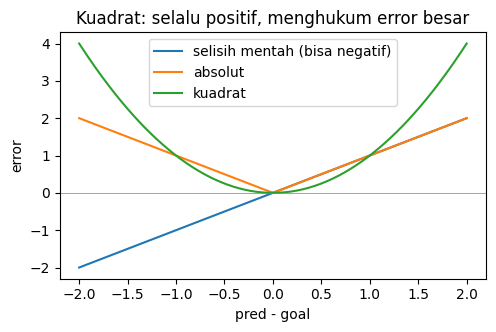

In [3]:
errors_raw = np.array([10.0, -10.0, 0.5, -0.5])
print('Selisih mentah :', errors_raw, '-> rata-rata', errors_raw.mean(), '(menyesatkan!)')
print('Absolut        :', np.abs(errors_raw), '-> rata-rata', np.abs(errors_raw).mean())
print('Kuadrat (MSE)  :', errors_raw ** 2, '-> rata-rata', (errors_raw ** 2).mean())

d = np.linspace(-2, 2, 200)
plt.figure(figsize=(5.5, 3.2))
plt.plot(d, d, label='selisih mentah (bisa negatif)')
plt.plot(d, np.abs(d), label='absolut')
plt.plot(d, d ** 2, label='kuadrat')
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel('pred - goal'); plt.ylabel('error'); plt.legend()
plt.title('Kuadrat: selalu positif, menghukum error besar')
plt.show()

## 3. Bentuk Learning Paling Sederhana: Hot and Cold Learning

Cara belajar paling naif: **coba geser bobot sedikit ke atas dan ke bawah**, lalu pilih arah yang errornya lebih kecil — seperti permainan "panas-dingin".

1. Prediksi dengan bobot saat ini → error.
2. Prediksi dengan `weight + step_amount` → `up_error`.
3. Prediksi dengan `weight - step_amount` → `down_error`.
4. Geser bobot ke arah dengan error terkecil.

In [4]:
weight = 0.5
input = 0.5
goal_prediction = 0.8
step_amount = 0.001

for iteration in range(1101):
    prediction = input * weight
    error = (prediction - goal_prediction) ** 2
    if iteration % 200 == 0 or iteration == 1100:
        print(f'Iter {iteration:4d}  Error: {error:.6f}  Prediction: {prediction:.4f}')

    up_prediction = input * (weight + step_amount)
    up_error = (goal_prediction - up_prediction) ** 2
    down_prediction = input * (weight - step_amount)
    down_error = (goal_prediction - down_prediction) ** 2

    if down_error < up_error:
        weight = weight - step_amount
    if down_error > up_error:
        weight = weight + step_amount

Iter    0  Error: 0.302500  Prediction: 0.2500
Iter  200  Error: 0.202500  Prediction: 0.3500
Iter  400  Error: 0.122500  Prediction: 0.4500
Iter  600  Error: 0.062500  Prediction: 0.5500
Iter  800  Error: 0.022500  Prediction: 0.6500
Iter 1000  Error: 0.002500  Prediction: 0.7500
Iter 1100  Error: 0.000000  Prediction: 0.8000


## 4. Karakteristik Hot and Cold Learning

Hot and cold learning **sederhana dan bekerja**, tetapi punya dua kelemahan besar:

1. **Tidak efisien** — perlu **3 prediksi** untuk setiap satu update bobot.
2. **Step size tetap** — kadang mustahil mencapai target yang tepat. Jika jarak ke target bukan kelipatan `step_amount`, bobot akan **bolak-balik** di sekitar jawaban selamanya. Jika step terlalu kecil, butuh ribuan iterasi (di atas: 1100 iterasi untuk masalah sesederhana ini).

Mari lihat masalah step size secara langsung:

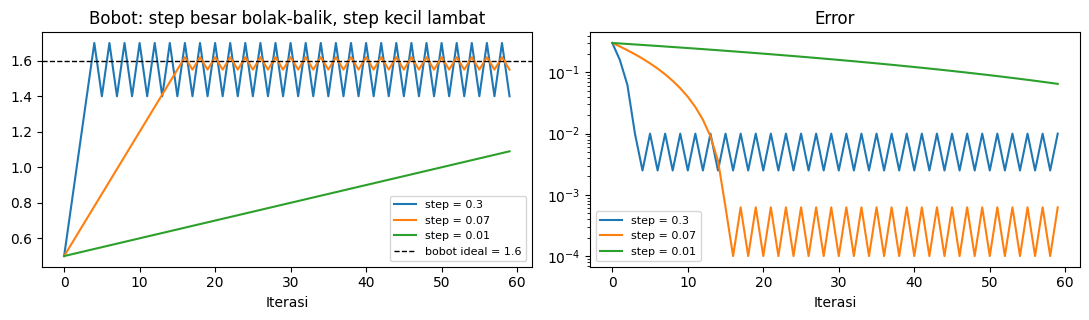

In [5]:
def hot_cold(step_amount, iters=60, weight=0.5, input=0.5, goal=0.8):
    ws, errs = [], []
    for _ in range(iters):
        pred = input * weight
        ws.append(weight); errs.append((pred - goal) ** 2)
        up = (input * (weight + step_amount) - goal) ** 2
        down = (input * (weight - step_amount) - goal) ** 2
        weight += -step_amount if down < up else step_amount
    return np.array(ws), np.array(errs)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
for step in [0.3, 0.07, 0.01]:
    ws, errs = hot_cold(step)
    axes[0].plot(ws, label=f'step = {step}')
    axes[1].plot(errs, label=f'step = {step}')
axes[0].axhline(1.6, color='k', ls='--', lw=1, label='bobot ideal = 1.6')
axes[0].set_title('Bobot: step besar bolak-balik, step kecil lambat'); axes[0].set_xlabel('Iterasi'); axes[0].legend(fontsize=8)
axes[1].set_yscale('log'); axes[1].set_title('Error'); axes[1].set_xlabel('Iterasi'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Solusinya: hitung **arah dan besar** perubahan langsung dari error, sehingga hanya butuh **satu** prediksi per update dan langkahnya otomatis mengecil saat mendekati target.

## 5. Menghitung Arah & Besar Perubahan dari Error

$$\text{direction\_and\_amount} = (\hat{y} - y) \times \text{input}$$

In [6]:
weight = 0.5
goal_pred = 0.8
input = 0.5

for iteration in range(20):
    pred = input * weight
    error = (pred - goal_pred) ** 2
    direction_and_amount = (pred - goal_pred) * input
    weight = weight - direction_and_amount
    if iteration % 4 == 0 or iteration == 19:
        print(f'Iter {iteration:2d}  Error: {error:.6f}  Prediction: {pred:.4f}')

Iter  0  Error: 0.302500  Prediction: 0.2500
Iter  4  Error: 0.030284  Prediction: 0.6260
Iter  8  Error: 0.003032  Prediction: 0.7449
Iter 12  Error: 0.000304  Prediction: 0.7826
Iter 16  Error: 0.000030  Prediction: 0.7945
Iter 19  Error: 0.000005  Prediction: 0.7977


Komponen-komponennya:
- **Pure error** `(pred - goal)` — memberi **arah** (positif = prediksi terlalu tinggi → turunkan bobot) dan **besar** kesalahan. Saat error kecil, langkahnya otomatis kecil.
- **Dikalikan input**, yang berfungsi sebagai tiga hal:

| Efek | Penjelasan |
|---|---|
| **Stopping** | Jika input = 0, bobot tidak diubah. Bobot itu tidak berkontribusi pada prediksi, jadi tidak boleh disalahkan. |
| **Negative reversal** | Jika input negatif, menaikkan bobot justru menurunkan prediksi. Mengalikan dengan input membalik arah update secara otomatis. |
| **Scaling** | Input besar → bobot berpengaruh besar pada prediksi → update besar. (Efek samping: bisa tidak stabil, lihat bagian 11.) |

In [7]:
goal = 0.8
for input in [0.0, -0.5, 0.5, 2.0]:
    weight = 0.5
    pred = input * weight
    step = (pred - goal) * input
    new_weight = weight - step
    print(f'input={input:5}: pred={pred:5.2f}, direction_and_amount={step:+.3f} -> '
          f'bobot {weight} -> {new_weight:.3f}, prediksi baru {input * new_weight:.3f}')

input=  0.0: pred= 0.00, direction_and_amount=-0.000 -> bobot 0.5 -> 0.500, prediksi baru 0.000
input= -0.5: pred=-0.25, direction_and_amount=+0.525 -> bobot 0.5 -> -0.025, prediksi baru 0.013
input=  0.5: pred= 0.25, direction_and_amount=-0.275 -> bobot 0.5 -> 0.775, prediksi baru 0.388
input=  2.0: pred= 1.00, direction_and_amount=+0.400 -> bobot 0.5 -> 0.100, prediksi baru 0.200


- `input = 0` → **stopping**: bobot tidak berubah.
- `input = -0.5` → **negative reversal**: bobot **turun** agar prediksi naik menuju 0.8.
- `input = 0.5` → bobot naik, prediksi mendekati 0.8.
- `input = 2.0` → **scaling**: perubahan terlalu besar sehingga prediksi melompati target (dibahas di bagian 11).

## 6. Satu Iterasi Gradient Descent

Istilah resmi dari buku:

| Variabel | Rumus | Arti |
|---|---|---|
| `delta` | $\hat{y} - y$ | seberapa jauh **prediksi (node)** meleset |
| `weight_delta` | $\delta \times x$ | seberapa besar & ke mana **bobot** perlu diubah (derivative) |
| update | $w \leftarrow w - \alpha \cdot \text{weight\_delta}$ | turun ke arah error lebih kecil |

In [8]:
weight, goal_pred, input = 0.1, 0.8, 1.1
alpha = 0.01

pred = input * weight
error = (pred - goal_pred) ** 2
delta = pred - goal_pred
weight_delta = input * delta
weight -= weight_delta * alpha

print(f'1. Predict : pred = {input} x 0.1 = {pred:.3f}')
print(f'2. Compare : error = ({pred:.3f} - {goal_pred})^2 = {error:.4f}, delta = {delta:.3f}')
print(f'3. Learn   : weight_delta = {input} x {delta:.3f} = {weight_delta:.4f}')
print(f'             weight = 0.1 - {weight_delta:.4f} x {alpha} = {weight:.5f}')

1. Predict : pred = 1.1 x 0.1 = 0.110
2. Compare : error = (0.110 - 0.8)^2 = 0.4761, delta = -0.690
3. Learn   : weight_delta = 1.1 x -0.690 = -0.7590
             weight = 0.1 - -0.7590 x 0.01 = 0.10759


### Learning is just reducing error
Mari lihat **beberapa langkah learning** (contoh dari buku: `weight = 0`, `input = 1.1`, `goal = 0.8`, tanpa alpha):

In [9]:
weight, goal_pred, input = 0.0, 0.8, 1.1

steps = []
for iteration in range(4):
    print(f'----- Iterasi {iteration}')
    print('Weight      :', round(weight, 4))
    pred = input * weight
    error = (pred - goal_pred) ** 2
    delta = pred - goal_pred
    weight_delta = delta * input
    steps.append((weight, error))
    weight = weight - weight_delta
    print('Error       :', round(error, 4), '| Prediction:', round(pred, 4))
    print('Delta       :', round(delta, 4), '| Weight Delta:', round(weight_delta, 4))

----- Iterasi 0
Weight      : 0.0
Error       : 0.64 | Prediction: 0.0
Delta       : -0.8 | Weight Delta: -0.88
----- Iterasi 1
Weight      : 0.88
Error       : 0.0282 | Prediction: 0.968
Delta       : 0.168 | Weight Delta: 0.1848
----- Iterasi 2
Weight      : 0.6952
Error       : 0.0012 | Prediction: 0.7647
Delta       : -0.0353 | Weight Delta: -0.0388
----- Iterasi 3
Weight      : 0.734
Error       : 0.0001 | Prediction: 0.8074
Delta       : 0.0074 | Weight Delta: 0.0081


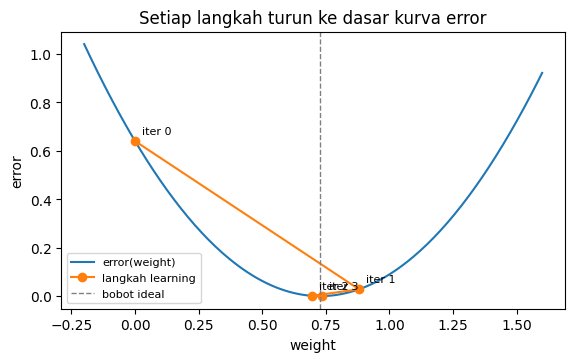

In [10]:
w_grid = np.linspace(-0.2, 1.6, 200)
err_grid = (input * w_grid - goal_pred) ** 2
steps = np.array(steps)

plt.figure(figsize=(6.5, 3.6))
plt.plot(w_grid, err_grid, label='error(weight)')
plt.plot(steps[:, 0], steps[:, 1], 'o-', color='C1', label='langkah learning')
for i, (w, e) in enumerate(steps):
    plt.annotate(f'iter {i}', (w, e), xytext=(5, 5), textcoords='offset points', fontsize=8)
plt.axvline(goal_pred / input, color='gray', ls='--', lw=1, label='bobot ideal')
plt.xlabel('weight'); plt.ylabel('error'); plt.legend(fontsize=8)
plt.title('Setiap langkah turun ke dasar kurva error')
plt.show()

Langkah pertama **melompati** titik minimum (dari 0 ke 0.88, padahal ideal 0.727), lalu langkah-langkah berikutnya bolak-balik dengan amplitudo yang makin kecil hingga konvergen.

## 7. Mengapa Ini Bekerja? Apa Sebenarnya `weight_delta`?

Fokus pada satu bobot. Kita ingin menemukan bobot yang membuat error = 0. Rumus error lengkapnya:

$$\text{error} = ((\text{input} \times \text{weight}) - \text{goal\_pred})^2$$

`input` dan `goal_pred` **tetap** (ditentukan data), sehingga **satu-satunya** yang bisa kita ubah adalah `weight`. Error adalah **fungsi dari bobot**. Pertanyaannya: *ke arah mana bobot harus digeser agar error turun, dan seberapa jauh?*

## 8. Tunnel Vision: Error sebagai Fungsi Bobot

Untuk input dan goal tertentu, kurva error vs bobot selalu berbentuk **mangkuk (parabola)**. Titik terendahnya adalah bobot yang membuat error = 0. Mengubah input atau goal hanya **menggeser/meregangkan** mangkuk tersebut.

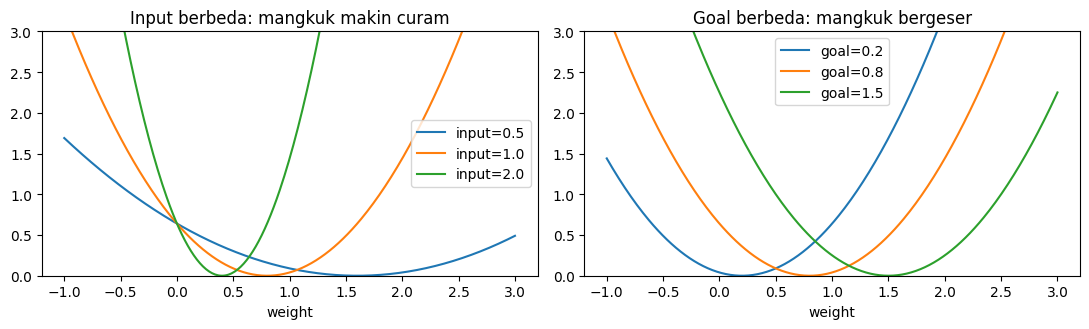

In [11]:
w = np.linspace(-1, 3, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for inp in [0.5, 1.0, 2.0]:
    axes[0].plot(w, (inp * w - 0.8) ** 2, label=f'input={inp}')
axes[0].set_ylim(0, 3); axes[0].set_title('Input berbeda: mangkuk makin curam'); axes[0].set_xlabel('weight'); axes[0].legend()
for goal in [0.2, 0.8, 1.5]:
    axes[1].plot(w, (1.0 * w - goal) ** 2, label=f'goal={goal}')
axes[1].set_ylim(0, 3); axes[1].set_title('Goal berbeda: mangkuk bergeser'); axes[1].set_xlabel('weight'); axes[1].legend()
plt.tight_layout(); plt.show()

## 9. A Box with Rods: Derivative secara Intuitif

Analogi Trask: bayangkan sebuah kotak dengan dua batang (*rods*) mencuat — batang biru dan batang merah — yang terhubung di dalam kotak dengan cara tertentu. Jika batang biru ditarik 1 cm, batang merah bergerak 2 cm. Hubungan "*bergerak 2 kali lipat*" inilah **derivative**: seberapa jauh satu variabel bergerak jika variabel lain digeser.

$$\frac{d(\text{merah})}{d(\text{biru})} = 2$$

Di neural network, kedua "batang" itu adalah **bobot** dan **error**. Derivative memberi tahu: *jika bobot digeser sedikit, berapa banyak error berubah?*

### Derivatives: take two
Cara lain memandang derivative: **kemiringan (slope)** sebuah garis atau kurva di satu titik.
- Slope **positif** → menaikkan bobot menaikkan error → **turunkan** bobot.
- Slope **negatif** → menaikkan bobot menurunkan error → **naikkan** bobot.
- Slope **besar** → kita masih jauh dari dasar mangkuk; slope **0** → kita sudah di dasar.

### What you really need to know
Kita **tidak perlu** menghafal semua aturan turunan kalkulus. Yang perlu dipahami: **derivative menghubungkan dua variabel**, dan memberi tahu **arah** serta **besar** perubahan. Kita memakai derivative untuk menemukan arah yang menurunkan error.

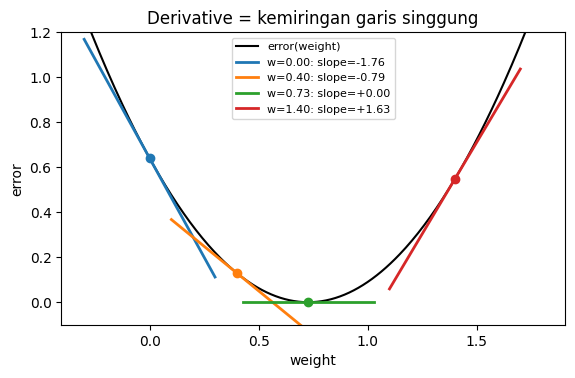

In [12]:
input, goal = 1.1, 0.8
w = np.linspace(-0.3, 1.8, 300)
err = (input * w - goal) ** 2

def derivative(weight):
    return 2 * (input * weight - goal) * input      # turunan analitik dari error

plt.figure(figsize=(6.5, 3.8))
plt.plot(w, err, 'k', label='error(weight)')
for w0, color in [(0.0, 'C0'), (0.4, 'C1'), (goal / input, 'C2'), (1.4, 'C3')]:
    e0, s = (input * w0 - goal) ** 2, derivative(w0)
    xs = np.linspace(w0 - 0.3, w0 + 0.3, 10)
    plt.plot(xs, e0 + s * (xs - w0), color=color, lw=2, label=f'w={w0:.2f}: slope={s:+.2f}')
    plt.scatter([w0], [e0], color=color, zorder=3)
plt.ylim(-0.1, 1.2); plt.xlabel('weight'); plt.ylabel('error'); plt.legend(fontsize=8)
plt.title('Derivative = kemiringan garis singgung')
plt.show()

In [13]:
# Verifikasi derivative analitik dengan "menarik batang" sedikit (aproksimasi numerik)
eps = 1e-6
for w0 in [0.0, 0.4, 1.4]:
    numeric = (((input * (w0 + eps) - goal) ** 2) - ((input * (w0 - eps) - goal) ** 2)) / (2 * eps)
    print(f'w={w0}: analitik={derivative(w0):+.6f}  numerik={numeric:+.6f}')

w=0.0: analitik=-1.760000  numerik=-1.760000
w=0.4: analitik=-0.792000  numerik=-0.792000
w=1.4: analitik=+1.628000  numerik=+1.628000


## 10. Memakai Derivative untuk Belajar

$$\frac{\partial\,\text{error}}{\partial w} = 2\,(x w - y)\,x \;\propto\; \underbrace{(\hat{y} - y)}_{\text{delta}} \cdot x = \text{weight\_delta}$$

Jadi `weight_delta` **adalah derivative** error terhadap bobot (faktor 2 diabaikan karena hanya mengubah skala dan diserap oleh learning rate). Gradient descent = **bergerak berlawanan arah derivative**:

```python
weight = weight - weight_delta   # turun ke arah error lebih kecil
```

### Look familiar?
Bandingkan dengan kode di bagian 5: `direction_and_amount = (pred - goal_pred) * input` — **persis sama**! Kita sudah memakai derivative sejak awal tanpa menyebutnya.

| Kode | Istilah kalkulus |
|---|---|
| `delta = pred - goal_pred` | derivative error terhadap prediksi (÷2) |
| `weight_delta = delta * input` | derivative error terhadap bobot (÷2) — *chain rule* |
| `weight -= weight_delta` | melangkah melawan arah gradien |

In [14]:
# Bandingkan jumlah prediksi: hot and cold vs gradient descent hingga error < 1e-6
def iters_to_converge(update, tol=1e-6, max_iter=10_000):
    weight, input, goal = 0.5, 0.5, 0.8
    for i in range(max_iter):
        pred = input * weight
        if (pred - goal) ** 2 < tol:
            return i
        weight = update(weight, input, goal, pred)
    return max_iter

def hc_update(w, x, y, p, step=0.001):
    up, down = (x * (w + step) - y) ** 2, (x * (w - step) - y) ** 2
    return w - step if down < up else w + step

def gd_update(w, x, y, p, alpha=1.0):
    return w - alpha * (p - y) * x

n_hc, n_gd = iters_to_converge(hc_update), iters_to_converge(gd_update)
print(f'Hot & cold      : {n_hc:5d} iterasi x 3 prediksi = {3 * n_hc} prediksi')
print(f'Gradient descent: {n_gd:5d} iterasi x 1 prediksi = {n_gd} prediksi')

Hot & cold      :  1099 iterasi x 3 prediksi = 3297 prediksi
Gradient descent:    22 iterasi x 1 prediksi = 22 prediksi


## 11. Merusak Gradient Descent: Overcorrection & Divergence

Apa yang terjadi jika input **besar**, misalnya `input = 2`? Karena `weight_delta = delta × input`, update menjadi terlalu besar — bobot **melompati** titik minimum (*overcorrection*), mendarat di sisi lain dengan error yang lebih besar, lalu melompat lebih jauh lagi... Error meledak. Ini disebut **divergence**.

In [15]:
weight, goal_pred, input = 0.5, 0.8, 2

div_hist = []
for iteration in range(20):
    pred = input * weight
    error = (pred - goal_pred) ** 2
    delta = pred - goal_pred
    weight_delta = input * delta
    div_hist.append((weight, error))
    weight = weight - weight_delta
    if iteration % 4 == 0 or iteration == 19:
        print(f'Iter {iteration:2d}  Error: {error:.3e}  Prediction: {pred:.3e}')

Iter  0  Error: 4.000e-02  Prediction: 1.000e+00
Iter  4  Error: 2.624e+02  Prediction: 1.700e+01
Iter  8  Error: 1.722e+06  Prediction: 1.313e+03
Iter 12  Error: 1.130e+10  Prediction: 1.063e+05
Iter 16  Error: 7.412e+13  Prediction: 8.609e+06
Iter 19  Error: 5.403e+16  Prediction: -2.325e+08


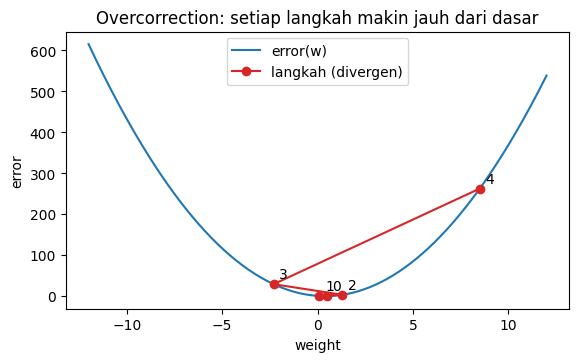

In [16]:
ws = np.array(div_hist[:5])
w_grid = np.linspace(-12, 12, 300)

plt.figure(figsize=(6.5, 3.6))
plt.plot(w_grid, (2 * w_grid - 0.8) ** 2, label='error(w)')
plt.plot(ws[:, 0], ws[:, 1], 'o-', color='C3', label='langkah (divergen)')
for i, (w_, e_) in enumerate(ws):
    plt.annotate(str(i), (w_, e_), xytext=(4, 4), textcoords='offset points')
plt.xlabel('weight'); plt.ylabel('error'); plt.legend()
plt.title('Overcorrection: setiap langkah makin jauh dari dasar')
plt.show()

**Mengapa?** Untuk input $x$, setiap update mengalikan selisih `pred - goal` dengan faktor $(1 - x^2)$ (atau $(1 - \alpha x^2)$ jika memakai alpha). Jika $|1 - \alpha x^2| > 1$, selisihnya membesar setiap iterasi. Untuk $x = 2$ dan $\alpha = 1$: faktor $= -3$ → error dikali 9 setiap iterasi.

## 12. Memperkenalkan Alpha

Solusinya sederhana: kalikan `weight_delta` dengan angka kecil **alpha** (α, *learning rate*) sebelum memperbarui bobot.

$$w \leftarrow w - \alpha \cdot \text{weight\_delta}$$

- α terlalu besar → divergence.
- α terlalu kecil → belajar sangat lambat.
- Dalam praktik, α biasanya ditebak dengan **orde besaran** (10, 1, 0.1, 0.01, ...) lalu dipilih yang errornya turun paling baik.

In [17]:
weight, goal_pred, input = 0.5, 0.8, 2
alpha = 0.1

for iteration in range(20):
    pred = input * weight
    error = (pred - goal_pred) ** 2
    derivative = input * (pred - goal_pred)
    weight = weight - alpha * derivative
    if iteration % 4 == 0 or iteration == 19:
        print(f'Iter {iteration:2d}  Error: {error:.8f}  Prediction: {pred:.6f}')

Iter  0  Error: 0.04000000  Prediction: 1.000000
Iter  4  Error: 0.00067185  Prediction: 0.825920
Iter  8  Error: 0.00001128  Prediction: 0.803359
Iter 12  Error: 0.00000019  Prediction: 0.800435
Iter 16  Error: 0.00000000  Prediction: 0.800056
Iter 19  Error: 0.00000000  Prediction: 0.800012


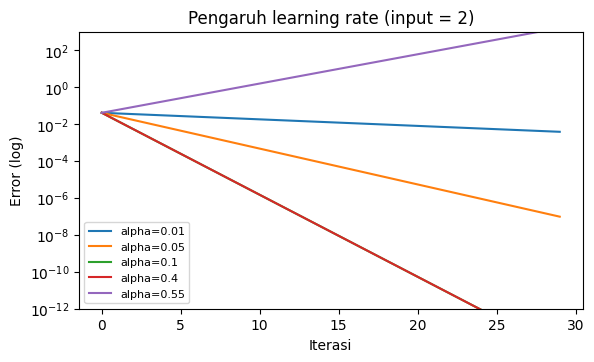

In [18]:
# Membandingkan beberapa alpha (input = 2): divergen bila |1 - 4*alpha| > 1, yaitu alpha > 0.5
plt.figure(figsize=(6.5, 3.6))
for alpha in [0.01, 0.05, 0.1, 0.4, 0.55]:
    w, errs = 0.5, []
    for _ in range(30):
        pred = 2 * w
        errs.append((pred - 0.8) ** 2)
        w -= alpha * 2 * (pred - 0.8)
    plt.plot(errs, label=f'alpha={alpha}')
plt.yscale('log'); plt.ylim(1e-12, 1e3)
plt.xlabel('Iterasi'); plt.ylabel('Error (log)'); plt.legend(fontsize=8)
plt.title('Pengaruh learning rate (input = 2)')
plt.show()

In [19]:
# Mencari alpha dengan orde besaran: error setelah 20 iterasi untuk input = 2
for alpha in [10, 1, 0.1, 0.01, 0.001]:
    w = 0.5
    for _ in range(20):
        w -= alpha * 2 * (2 * w - 0.8)
    print(f'alpha={alpha:<6}: error akhir = {(2 * w - 0.8) ** 2:.3e}')

alpha=10    : error akhir = 1.756e+62
alpha=1     : error akhir = 4.863e+17
alpha=0.1   : error akhir = 5.347e-11
alpha=0.01  : error akhir = 7.815e-03
alpha=0.001 : error akhir = 3.407e-02


Di antara orde besaran yang dicoba, `0.1` memberikan error terkecil; `10` dan `1` divergen, sedangkan `0.01` dan `0.001` terlalu lambat.

## 13. Memorizing — Kode Lengkap

Trask menyarankan untuk **menghafal** kode gradient descent berikut (bisa menulis ulang tanpa melihat). Kode inilah fondasi semua bab berikutnya.

In [20]:
weight = 0.5
goal_pred = 0.8
input = 2
alpha = 0.1

for iteration in range(20):
    pred = input * weight
    error = (pred - goal_pred) ** 2
    derivative = input * (pred - goal_pred)
    weight = weight - (alpha * derivative)

print('Error:', error, '| Prediction:', pred)

Error: 1.485277170987127e-10 | Prediction: 0.8000121871948003


## Latihan

1. Untuk `input = 0.5`, `goal = 0.8`, berapa nilai alpha **terbesar** yang masih konvergen? (Petunjuk: $|1 - \alpha x^2| < 1$.) Verifikasi dengan simulasi.
2. Ubah `goal` menjadi negatif (`-0.5`) dengan `input = 1.5`. Apakah gradient descent tetap bekerja tanpa mengubah kode?

### Contoh solusi

In [21]:
# Latihan 1: alpha < 2 / x^2 = 2 / 0.25 = 8
for alpha in [7.9, 8.1]:
    w = 0.5
    for _ in range(100):
        w -= alpha * 0.5 * (0.5 * w - 0.8)
    print(f'alpha={alpha}: error setelah 100 iterasi = {(0.5 * w - 0.8) ** 2:.3e}')

# Latihan 2
w, x, goal = 0.5, 1.5, -0.5
for _ in range(30):
    w -= 0.1 * x * (x * w - goal)
print(f'\ngoal negatif: prediksi akhir = {x * w:.4f} (target -0.5), bobot = {w:.4f}')

alpha=7.9: error setelah 100 iterasi = 1.913e-03
alpha=8.1: error setelah 100 iterasi = 4.222e+01

goal negatif: prediksi akhir = -0.4994 (target -0.5), bobot = -0.3329


## Rangkuman Bab 4

- Neural network belajar dengan siklus **predict → compare → learn**.
- **Squared error** $(\hat{y}-y)^2$ selalu positif dan memprioritaskan error besar; mengukur error menyederhanakan tujuan menjadi "turunkan angka ini ke 0".
- **Hot and cold learning** sederhana tetapi boros (3 prediksi per update) dan bergantung pada step size tetap.
- `direction_and_amount = (pred - goal) × input` memberi arah & besar perubahan sekaligus; perkalian input memberi efek **stopping**, **negative reversal**, dan **scaling**.
- **Gradient descent**: `delta = pred - goal`, `weight_delta = delta * input`, `weight -= alpha * weight_delta`.
- `weight_delta` adalah **derivative** error terhadap bobot — slope kurva error (analogi *box with rods*); kita bergerak berlawanan arah slope menuju dasar mangkuk.
- Input besar menyebabkan **overcorrection** dan **divergence**; diatasi dengan **alpha (learning rate)** yang dipilih berdasarkan orde besaran.